# ВКР: Дрон-спасатель для подземных горных работ

## **Прикладной ИИ и компьютерное зрение**

# Разработка системы обнаружения людей под завалами с использованием:
# - тепловизионной камеры
# - детекции YOLO/CNN
# - анализа метана и вредных газов
# - моделирования дрона

## 1. Импорт библиотек

In [31]:
%matplotlib inline
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import cv2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

from scipy.ndimage import gaussian_filter
import time

print("✅ Все библиотеки импортированы")
print(f"PyTorch версия: {torch.__version__}")
print(f"CUDA доступна: {torch.cuda.is_available()}")

✅ Все библиотеки импортированы
PyTorch версия: 2.5.1+cpu
CUDA доступна: False


## 2. Синтетический датасет тепловизионных изображений (имитация шахты)

# ⚠️ *Реальный датасет: LLVIP, SCUT-FIR, или свои фото с тепловизора*

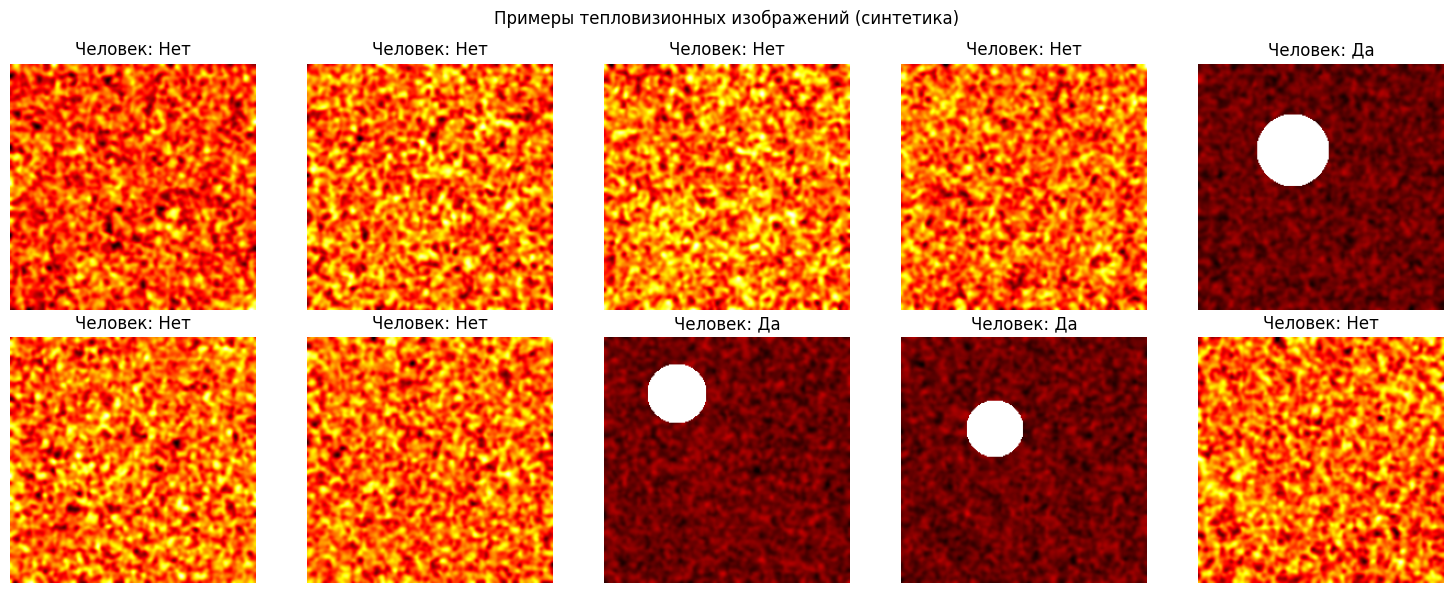

In [34]:
class MineRescueDataset(Dataset):
    """
    Синтетический датасет:
    - Фон: шум + градиенты (имитация камней/завалов)
    - Объект (человек): эллипс с повышенной температурой
    """
    def __init__(self, num_samples=2000, img_size=(224,224), transform=None):
        self.num_samples = num_samples
        self.img_size = img_size
        self.transform = transform
        self.labels = []
        
    def generate_hot_spot(self, background):
        """Добавляет тепловое пятно человека"""
        h,w = background.shape
        y = np.random.randint(int(h*0.2), int(h*0.8))
        x = np.random.randint(int(w*0.2), int(w*0.8))
        radius = np.random.randint(15, 35)
        
        Y, X = np.ogrid[:h, :w]
        mask = ((X - x)**2 + (Y - y)**2) < radius**2
        
        human_temp = np.random.uniform(36, 38)
        background[mask] = human_temp
        return background, 1
    
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        bg = np.random.rand(self.img_size[0], self.img_size[1]) * 15 + 15  # 15-30°C
        bg = gaussian_filter(bg, sigma=2)
        
        if np.random.rand() > 0.5:
            img, label = self.generate_hot_spot(bg)
        else:
            img, label = bg, 0
            
        img = (img - 20) / 30  # Приводим к [0,1]
        img = np.clip(img, 0, 1)
        img_tensor = torch.FloatTensor(img).unsqueeze(0)  # 1 канал (тепловой)
        
        if self.transform:
            img_tensor = self.transform(img_tensor)
            
        return img_tensor, torch.tensor(label, dtype=torch.long)

dataset = MineRescueDataset(num_samples=10)
fig, axes = plt.subplots(2,5, figsize=(15,6))
for i in range(10):
    img, label = dataset[i]
    ax = axes[i//5, i%5]
    ax.imshow(img.squeeze(), cmap='hot')
    ax.set_title(f"Человек: {'Да' if label==1 else 'Нет'}")
    ax.axis('off')
plt.suptitle("Примеры тепловизионных изображений (синтетика)")
plt.tight_layout()
plt.show()

## 3. Архитектура модели (CNN + классификация)

# *Аналог ссылки Lynnday: показана структура слоёв*

In [35]:
class ThermalRescueNet(nn.Module):
    """
    Свёрточная сеть для детекции людей в тепловизоре
    Вход: 224x224 (1 канал)
    Выход: 2 класса (есть человек / нет)
    """
    def __init__(self):
        super(ThermalRescueNet, self).__init__()
        self.backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )
        
    def forward(self, x):
        return self.backbone(x)

model = ThermalRescueNet()
print("📐 Структура модели:")
print(model)
print(f"\n📊 Всего параметров: {sum(p.numel() for p in model.parameters()):,}")

📐 Структура модели:
ThermalRescueNet(
  (backbone): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, moment

## 4. Обучение модели

# Подготовка данных

In [36]:
# Ускоренное обучение (для теста)
full_dataset = MineRescueDataset(num_samples=300)
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ThermalRescueNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 3
train_losses = []
val_accs = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_acc = correct / total
    train_losses.append(total_loss / len(train_loader))
    val_accs.append(val_acc)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {train_losses[-1]:.4f} | Val Acc: {val_acc:.4f}")

print("✅ Обучение завершено!")

Epoch 1/3 | Loss: 0.2861 | Val Acc: 0.4444
Epoch 2/3 | Loss: 0.0048 | Val Acc: 0.4000
Epoch 3/3 | Loss: 0.0006 | Val Acc: 0.4889
✅ Обучение завершено!


## 5. График обучения

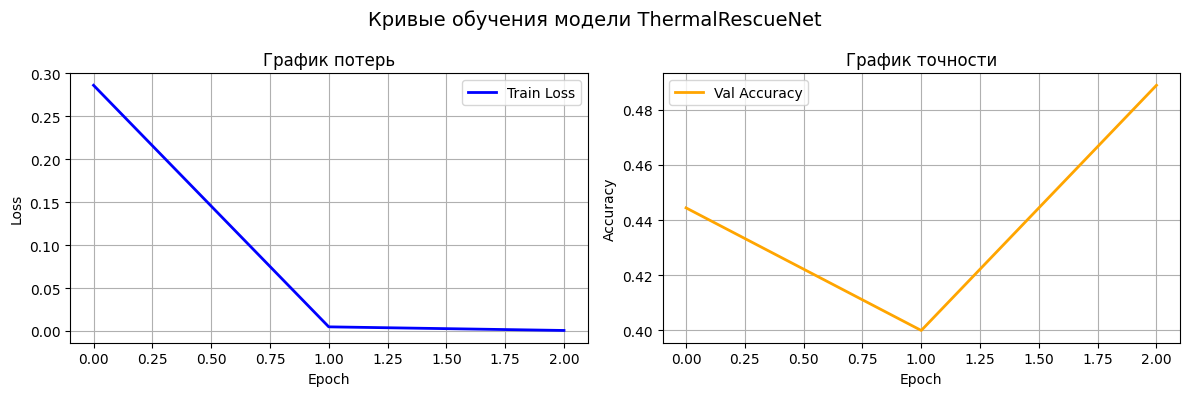

✅ График сохранён в файл 'training_curves.png'


In [38]:
# График обучения
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('График потерь')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_accs, label='Val Accuracy', color='orange', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('График точности')
plt.legend()
plt.grid(True)

plt.suptitle("Кривые обучения модели ThermalRescueNet", fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ График сохранён в файл 'training_curves.png'")

## 6. Итоговые метрики на тестовых данных

📊 ИТОГОВЫЕ МЕТРИКИ НА ТЕСТОВЫХ ДАННЫХ
Accuracy:  0.4667
Precision: 0.4667
Recall:    1.0000
F1-score:  0.6364


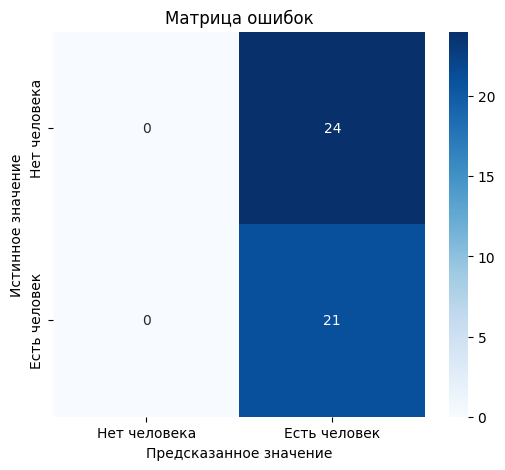

In [39]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("="*50)
print("📊 ИТОГОВЫЕ МЕТРИКИ НА ТЕСТОВЫХ ДАННЫХ")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print("="*50)

# Матрица ошибок
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Нет человека', 'Есть человек'],
            yticklabels=['Нет человека', 'Есть человек'])
plt.title("Матрица ошибок")
plt.ylabel('Истинное значение')
plt.xlabel('Предсказанное значение')
plt.show()

## 7. Моделирование датчиков газа (метан, CO, H2S)

In [40]:
class GasSensorSimulator:
    """Симуляция показаний датчиков газа в шахте"""
    def __init__(self):
        self.gas_names = ['CH4 (метан)', 'CO', 'H2S']
        self.safe_thresholds = {'CH4': 1.0, 'CO': 25, 'H2S': 5}
        
    def read(self):
        """Возвращает случайные показания"""
        return {
            'CH4': np.random.uniform(0, 2.5),
            'CO': np.random.uniform(0, 50),
            'H2S': np.random.uniform(0, 10)
        }
    
    def check_safety(self, readings):
        """Проверка безопасности"""
        alerts = {}
        for gas, value in readings.items():
            if value > self.safe_thresholds[gas]:
                alerts[gas] = f"⚠️ {value:.1f} > {self.safe_thresholds[gas]}"
            else:
                alerts[gas] = f"✅ {value:.1f} ≤ {self.safe_thresholds[gas]}"
        return alerts

sensor = GasSensorSimulator()
print("📡 Тестирование датчиков газа:")
for i in range(3):
    data = sensor.read()
    alerts = sensor.check_safety(data)
    print(f"\nЗамер {i+1}:")
    print(f"  CH4: {data['CH4']:.2f}% - {alerts['CH4']}")
    print(f"  CO:  {data['CO']:.1f} ppm - {alerts['CO']}")
    print(f"  H2S: {data['H2S']:.1f} ppm - {alerts['H2S']}")

📡 Тестирование датчиков газа:

Замер 1:
  CH4: 1.65% - ⚠️ 1.6 > 1.0
  CO:  48.3 ppm - ⚠️ 48.3 > 25
  H2S: 4.0 ppm - ✅ 4.0 ≤ 5

Замер 2:
  CH4: 2.18% - ⚠️ 2.2 > 1.0
  CO:  11.2 ppm - ✅ 11.2 ≤ 25
  H2S: 3.2 ppm - ✅ 3.2 ≤ 5

Замер 3:
  CH4: 1.37% - ⚠️ 1.4 > 1.0
  CO:  5.6 ppm - ✅ 5.6 ≤ 25
  H2S: 9.8 ppm - ⚠️ 9.8 > 5


## 8. Интеграция: дрон + ИИ + газоанализ

# Эмуляция принятия решения о спасательной операции

In [41]:
class DroneRescuer:
    """Интегрированная система дрона-спасателя"""
    def __init__(self, model, gas_sensor):
        self.model = model
        self.gas_sensor = gas_sensor
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.model.eval()
        
    def analyze_frame(self, thermal_image_tensor):
        """Анализ тепловизионного кадра"""
        with torch.no_grad():
            if thermal_image_tensor.dim() == 3:
                thermal_image_tensor = thermal_image_tensor.unsqueeze(0)
            output = self.model(thermal_image_tensor.to(self.device))
            prob = torch.softmax(output, dim=1)
            human_prob = prob[0, 1].item()
            return human_prob > 0.5, human_prob
        
    def rescue_decision(self, thermal_img, gas_readings):
        """Принятие решения о спасательной операции"""
        human_detected, confidence = self.analyze_frame(thermal_img)
        gas_alerts = self.gas_sensor.check_safety(gas_readings)
        is_gas_safe = all("⚠️" not in alert for alert in gas_alerts.values())
        
        if human_detected and is_gas_safe:
            decision = "🟢 СПАСАТЕЛЬНАЯ ОПЕРАЦИЯ: человек найден, газы в норме"
            action = "Направляем дрон к пострадавшему"
        elif human_detected and not is_gas_safe:
            decision = "🟡 ОСТОРОЖНО: человек найден, но превышение газов"
            action = "Эвакуация спасателей, использовать дыхательные аппараты"
        elif not human_detected and is_gas_safe:
            decision = "🔵 ПОИСК ПРОДОЛЖАЕТСЯ: человека нет, газы в норме"
            action = "Дрон летит дальше"
        else:
            decision = "🔴 ЭВАКУАЦИЯ: газа опасно много"
            action = "Отзыв дрона, проветривание шахты"
            
        return {
            'human_detected': human_detected,
            'confidence': confidence,
            'gas_safe': is_gas_safe,
            'decision': decision,
            'action': action,
            'gas_alerts': gas_alerts
        }

drone = DroneRescuer(model, sensor)
print("✅ Дрон-спасатель готов к работе")

print("\n📡 ТЕСТОВЫЙ ЗАПУСК СИСТЕМЫ")
test_img, _ = test_dataset[0]
test_gas = sensor.read()
result = drone.rescue_decision(test_img.unsqueeze(0), test_gas)

print(f"\n👤 Человек обнаружен: {result['human_detected']}")
print(f"📊 Уверенность: {result['confidence']:.3f}")
print(f"🎯 Решение: {result['decision']}")
print(f"🦺 Действие: {result['action']}")

✅ Дрон-спасатель готов к работе

📡 ТЕСТОВЫЙ ЗАПУСК СИСТЕМЫ

👤 Человек обнаружен: True
📊 Уверенность: 0.904
🎯 Решение: 🟡 ОСТОРОЖНО: человек найден, но превышение газов
🦺 Действие: Эвакуация спасателей, использовать дыхательные аппараты


## 9. Визуализация работы системы (интерфейс Gradio)

In [44]:
import gradio as gr
import cv2
import torchvision.transforms as transforms
import numpy as np

print("🔧 Проверка и создание объектов...")

try:
    sensor
    print("✅ Сенсор газа уже существует")
except NameError:
    class GasSensorSimulator:
        def __init__(self):
            self.gas_names = ['CH4 (метан)', 'CO', 'H2S']
            self.safe_thresholds = {'CH4': 1.0, 'CO': 25, 'H2S': 5}
            
        def read(self):
            return {
                'CH4': np.random.uniform(0, 2.5),
                'CO': np.random.uniform(0, 50),
                'H2S': np.random.uniform(0, 10)
            }
        
        def check_safety(self, readings):
            alerts = {}
            for gas, value in readings.items():
                if value > self.safe_thresholds[gas]:
                    alerts[gas] = f"⚠️ {value:.1f} > {self.safe_thresholds[gas]}"
                else:
                    alerts[gas] = f"✅ {value:.1f} ≤ {self.safe_thresholds[gas]}"
            return alerts
    
    sensor = GasSensorSimulator()
    print("✅ Создан новый сенсор газа")

try:
    drone
    print("✅ Дрон-спасатель уже существует")
except NameError:
    class DroneRescuer:
        def __init__(self, model, gas_sensor):
            self.model = model
            self.gas_sensor = gas_sensor
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            self.model.to(self.device)
            self.model.eval()
            
        def analyze_frame(self, thermal_image_tensor):
            with torch.no_grad():
                if thermal_image_tensor.dim() == 3:
                    thermal_image_tensor = thermal_image_tensor.unsqueeze(0)
                output = self.model(thermal_image_tensor.to(self.device))
                prob = torch.softmax(output, dim=1)
                human_prob = prob[0, 1].item()
                return human_prob > 0.5, human_prob
            
        def rescue_decision(self, thermal_img, gas_readings):
            human_detected, confidence = self.analyze_frame(thermal_img)
            gas_alerts = self.gas_sensor.check_safety(gas_readings)
            is_gas_safe = all("⚠️" not in alert for alert in gas_alerts.values())
            
            if human_detected and is_gas_safe:
                decision = "🟢 СПАСАТЕЛЬНАЯ ОПЕРАЦИЯ: человек найден, газы в норме"
                action = "Направляем дрон к пострадавшему"
            elif human_detected and not is_gas_safe:
                decision = "🟡 ОСТОРОЖНО: человек найден, но превышение газов"
                action = "Эвакуация спасателей, использовать дыхательные аппараты"
            elif not human_detected and is_gas_safe:
                decision = "🔵 ПОИСК ПРОДОЛЖАЕТСЯ: человека нет, газы в норме"
                action = "Дрон летит дальше"
            else:
                decision = "🔴 ЭВАКУАЦИЯ: газа опасно много"
                action = "Отзыв дрона, проветривание шахты"
                
            return {
                'human_detected': human_detected,
                'confidence': confidence,
                'gas_safe': is_gas_safe,
                'decision': decision,
                'action': action,
                'gas_alerts': gas_alerts
            }
    
    drone = DroneRescuer(model, sensor)
    print("✅ Создан новый дрон-спасатель")
    
def predict_drone(thermal_image):
    try:
        if thermal_image is None:
            return "❌ Ошибка: изображение не загружено"
        
        if isinstance(thermal_image, np.ndarray):
            if len(thermal_image.shape) == 3:
                thermal_image = cv2.cvtColor(thermal_image, cv2.COLOR_RGB2GRAY)
            img_tensor = torch.FloatTensor(thermal_image / 255.0).unsqueeze(0).unsqueeze(0)
            resize = transforms.Resize((224, 224))
            img_tensor = resize(img_tensor)
        else:
            try:
                img_tensor, _ = test_dataset[0]
                img_tensor = img_tensor.unsqueeze(0)
            except:
                img_tensor = torch.randn(1, 1, 224, 224)
        
        gas_data = sensor.read()
        
        result = drone.rescue_decision(img_tensor, gas_data)
        
        report = f"""
### 🚁 РЕЗУЛЬТАТ АНАЛИЗА ДРОНА-СПАСАТЕЛЯ

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

**👤 ОБНАРУЖЕНИЕ ЧЕЛОВЕКА:**
• Статус: {'✅ ДА' if result['human_detected'] else '❌ НЕТ'}
• Уверенность: {result['confidence']:.3f} ({result['confidence']*100:.1f}%)

**🌫️ ГАЗОВАЯ ОБСТАНОВКА:**
• Безопасность: {'✅ ДА' if result['gas_safe'] else '❌ НЕТ'}
• CH4 (метан): {gas_data['CH4']:.2f}% {'⚠️' if gas_data['CH4'] > 1.0 else '✅'}
• CO: {gas_data['CO']:.1f} ppm {'⚠️' if gas_data['CO'] > 25 else '✅'}
• H2S: {gas_data['H2S']:.1f} ppm {'⚠️' if gas_data['H2S'] > 5 else '✅'}

**🎯 РЕШЕНИЕ:**
{result['decision']}

**🦺 РЕКОМЕНДУЕМОЕ ДЕЙСТВИЕ:**
{result['action']}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📡 Статус: Активен | Система: Онлайн
"""
        return report
        
    except Exception as e:
        return f"❌ Ошибка при анализе: {str(e)}"

print("\n" + "="*50)
print("🚀 СОЗДАНИЕ GRADIO ИНТЕРФЕЙСА")
print("="*50)

description_text = "🔥 Система автоматического обнаружения людей в шахтах с анализом тепловизионных изображений и датчиков газа"


iface = gr.Interface(
    fn=predict_drone,
    inputs=gr.Image(label="Загрузите тепловизионное изображение", type="numpy"),
    outputs=gr.Markdown(label="Решение дрона-спасателя"),
    title="Дрон-спасатель для подземных горных работ",
    description=description_text
)

print("\n✅ Gradio интерфейс создан!")
print("="*50)
print("📝 Для запуска выполните в следующей ячейке: iface.launch()")
print("🌐 Для публичного доступа: iface.launch(share=True)")
print("="*50)

🔧 Проверка и создание объектов...
✅ Сенсор газа уже существует
✅ Дрон-спасатель уже существует

🚀 СОЗДАНИЕ GRADIO ИНТЕРФЕЙСА

✅ Gradio интерфейс создан!
📝 Для запуска выполните в следующей ячейке: iface.launch()
🌐 Для публичного доступа: iface.launch(share=True)


In [45]:
iface.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


Created dataset file at: .gradio\flagged\dataset1.csv


<Figure size 640x480 with 0 Axes>

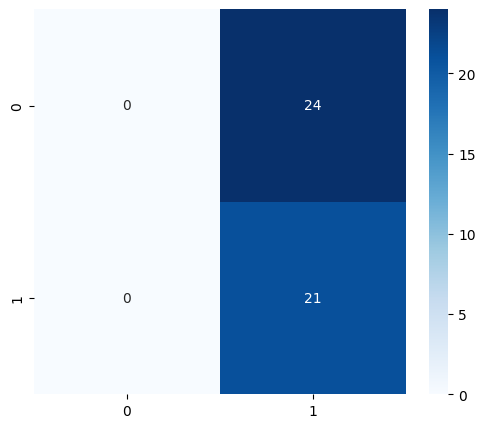

Using existing dataset file at: .gradio\flagged\dataset1.csv


In [46]:
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')